# 🧪 Validación e Inferencia con Modelos Serializados (.joblib)
### **Sistema GeoAI de Prospectividad Mineral en España (Walter Pohl 2011 + 14 Capas Reales)**

Este cuaderno contiene la suite oficial de pruebas para verificar, cargar y ejecutar inferencias con los **4 modelos calibrados de Machine Learning** serializados en disco:
* 👑 **Oro ($Y_{\text{Au}}$):** `model_geoai_Au_Oro.joblib`
* 🥉 **Cobre ($Y_{\text{Cu}}$):** `model_geoai_Cu_Cobre.joblib`
* 🥈 **Plata ($Y_{\text{Ag}}$):** `model_geoai_Ag_Plata.joblib`
* ⚙️ **Plomo ($Y_{\text{Pb}}$):** `model_geoai_Pb_Plomo.joblib`

---

In [1]:
import os
import joblib
import pandas as pd
import numpy as np

# Rutas a los modelos
MODELS = {
    'Au_Oro': 'model_geoai_Au_Oro.joblib',
    'Cu_Cobre': 'model_geoai_Cu_Cobre.joblib',
    'Ag_Plata': 'model_geoai_Ag_Plata.joblib',
    'Pb_Plomo': 'model_geoai_Pb_Plomo.joblib'
}

loaded_models = {}
metrics_summary = []

print("📦 1. CARGANDO Y VERIFICANDO MODELOS .JOBLIB:")
print("=" * 75)

for ckey, filename in MODELS.items():
    possible_paths = [
        filename,
        os.path.join('..', 'models', filename),
        os.path.join('models', filename),
        os.path.join('C:/Users/mdmat/Desktop/Recursos Curso EOI/geoai-mineria-romana-espana/models', filename)
    ]
    path = next((p for p in possible_paths if os.path.exists(p)), filename)
    bundle = joblib.load(path)
    loaded_models[ckey] = bundle
    
    m = bundle['metrics']
    metrics_summary.append({
        'Commodity': ckey,
        'Spatial ROC-AUC': f"{m['roc_auc']:.4f}",
        'Spatial PR-AUC': f"{m['pr_auc']:.4f}",
        'Brier Score': f"{m['brier']:.4f}",
        'F1-Score': f"{m['f1']:.4f}",
        'Nº Variables': len(bundle['features'])
    })
    print(f"✅ {ckey:10s} -> Cargado con éxito | Variables: {len(bundle['features'])} | ROC-AUC: {m['roc_auc']:.4f} | Brier: {m['brier']:.4f}")

print("=" * 75)
pd.DataFrame(metrics_summary)

📦 1. CARGANDO Y VERIFICANDO MODELOS .JOBLIB:


✅ Au_Oro     -> Cargado con éxito | Variables: 19 | ROC-AUC: 0.9157 | Brier: 0.1029
✅ Cu_Cobre   -> Cargado con éxito | Variables: 19 | ROC-AUC: 0.8524 | Brier: 0.0869
✅ Ag_Plata   -> Cargado con éxito | Variables: 19 | ROC-AUC: 0.8876 | Brier: 0.0775
✅ Pb_Plomo   -> Cargado con éxito | Variables: 19 | ROC-AUC: 0.8925 | Brier: 0.0900


,Commodity,Spatial ROC-AUC,Spatial PR-AUC,Brier Score,F1-Score,Nº Variables
0,Au_Oro,0.9157,0.3849,0.1029,0.0897,19
1,Cu_Cobre,0.8524,0.4392,0.0869,0.2258,19
2,Ag_Plata,0.8876,0.5922,0.0775,0.4808,19
3,Pb_Plomo,0.8925,0.6020,0.0900,0.4623,19


In [2]:
def predict_mineral_prospectivity(
    lat, lng,
    elevation_m=500.0,
    lithology="Cuarcitas; pizarras; areniscas; calizas y vulcanitas",
    era="PALEOZOICO",
    dominio="MACIZO IBERICO",
    dist_fault_m=2500.0,
    dist_contact_m=1200.0,
    fault_density_5km=8,
    bouguer_mgal=-60.0,
    magnetic_field_nt=44800.0,
    magnetic_gradient=0.35,
    as_ppm=18.0,
    sb_ppm=1.2,
    cu_ppm=25.0,
    pb_ppm=28.0,
    zn_ppm=65.0,
    clay_sericite_index=1.35,
    gossan_feox_index=1.25,
    location_name="Ubicación de Prueba"
):
    """
    Ejecuta la inferencia completa con los 4 modelos calibrados (.joblib)
    para cualquier punto del territorio peninsular con sus 14 variables geocientíficas.
    """
    # Conversión aproximada WGS84 -> EPSG:25830 (UTM 30N) si no se proporcionan
    coord_x = 500000.0 + (lng + 3.0) * 88000.0
    coord_y = 4400000.0 + (lat - 40.0) * 111000.0
    
    # Crear DataFrame con el esquema exacto de 14 capas
    df_point = pd.DataFrame([{
        'Real_Elevation_MDT_m': elevation_m,
        'Real_IGME_Dist_Fault_m': dist_fault_m,
        'Real_IGME_Dist_Contact_m': dist_contact_m,
        'Real_IGME_Fault_Density_5km': fault_density_5km,
        'Real_Bouguer_Anomaly_mGal': bouguer_mgal,
        'Real_Total_Magnetic_Field_nT': magnetic_field_nt,
        'Real_Magnetic_Gradient_nTm': magnetic_gradient,
        'Real_Geochem_As_ppm': as_ppm,
        'Real_Geochem_Sb_ppm': sb_ppm,
        'Real_Geochem_Cu_ppm': cu_ppm,
        'Real_Geochem_Pb_ppm': pb_ppm,
        'Real_Geochem_Zn_ppm': zn_ppm,
        'Real_Remote_Clay_Sericite_Index': clay_sericite_index,
        'Real_Remote_Gossan_FeOx_Index': gossan_feox_index,
        'Coord_X': coord_x,
        'Coord_Y': coord_y,
        'Real_IGME_Lithology_General': lithology,
        'Real_IGME_Era': era,
        'Real_IGME_Dominio': dominio
    }])
    
    # Predecir con los 4 modelos
    p_au = loaded_models['Au_Oro']['model'].predict_proba(df_point)[0, 1]
    p_cu = loaded_models['Cu_Cobre']['model'].predict_proba(df_point)[0, 1]
    p_ag = loaded_models['Ag_Plata']['model'].predict_proba(df_point)[0, 1]
    p_pb = loaded_models['Pb_Plomo']['model'].predict_proba(df_point)[0, 1]
    
    print(f"\n🎯 INFORME GEOAI: {location_name.upper()}")
    print(f"📍 Coordenadas: Lat {lat:.4f}° N, Lng {lng:.4f}° W | Altitud: {elevation_m:.1f} m")
    print(f"🪨 Litología: {lithology} ({era} / {dominio})")
    print("-" * 65)
    
    results = [
        ('🥇 ORO (Y_Au)', p_au, '#f59e0b'),
        ('🥉 COBRE (Y_Cu)', p_cu, '#ea580c'),
        ('🥈 PLATA (Y_Ag)', p_ag, '#cbd5e1'),
        ('⚙️ PLOMO (Y_Pb)', p_pb, '#3b82f6')
    ]
    
    for name, p, color in results:
        bar_len = int(p * 30)
        bar = "█" * bar_len + "░" * (30 - bar_len)
        veredicto = "🚨 ALTA FAVORABILIDAD" if p >= 0.50 else ("⚠️ Interés Medio" if p >= 0.25 else "⚪ Baja")
        print(f"{name:18s}: [{bar}] {p*100:6.2f}% -> {veredicto}")
        
    print("-" * 65)
    return {'p_au': p_au, 'p_cu': p_cu, 'p_ag': p_ag, 'p_pb': p_pb}

### 🧪 Prueba 1: Mina de Oro de Salave (Tapia de Casariego, Asturias)
Stock granodiorítico intrusivo en el zócalo paleozoico varisco con halo de arsenopirita y estibina.

In [3]:
res_salave = predict_mineral_prospectivity(
    lat=43.5615, lng=-6.9378,
    elevation_m=30.0,
    lithology="Cuarcitas; pizarras; areniscas; calizas y vulcanitas",
    era="PALEOZOICO",
    dominio="MACIZO IBERICO",
    dist_fault_m=850.0,
    dist_contact_m=210.0,
    fault_density_5km=14,
    bouguer_mgal=-45.0,
    as_ppm=280.0, # Halo masivo de As en Salave
    sb_ppm=24.0,
    cu_ppm=18.0,
    pb_ppm=22.0,
    clay_sericite_index=1.62,
    gossan_feox_index=1.45,
    location_name="Mina de Oro de Salave (Asturias)"
)


🎯 INFORME GEOAI: MINA DE ORO DE SALAVE (ASTURIAS)
📍 Coordenadas: Lat 43.5615° N, Lng -6.9378° W | Altitud: 30.0 m
🪨 Litología: Cuarcitas; pizarras; areniscas; calizas y vulcanitas (PALEOZOICO / MACIZO IBERICO)
-----------------------------------------------------------------
🥇 ORO (Y_Au)      : [██████████░░░░░░░░░░░░░░░░░░░░]  33.34% -> ⚠️ Interés Medio
🥉 COBRE (Y_Cu)    : [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   3.34% -> ⚪ Baja
🥈 PLATA (Y_Ag)    : [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   3.87% -> ⚪ Baja
⚙️ PLOMO (Y_Pb)   : [███████░░░░░░░░░░░░░░░░░░░░░░░]  24.19% -> ⚪ Baja
-----------------------------------------------------------------


### 🧪 Prueba 2: Minas de Riotinto (Faja Pirítica Ibérica, Huelva)
Arquetipo de sulfuros masivos volcanogénicos (VMS) con alta densidad Bouguer y complejo volcano-sedimentario.

In [4]:
res_riotinto = predict_mineral_prospectivity(
    lat=37.6930, lng=-6.5940,
    elevation_m=422.0,
    lithology="Conglomerados; areniscas; pizarras; calizas y vulcanitas; Carbon",
    era="PALEOZOICO",
    dominio="ZONA SUDPORTUGUESA / FAJA PIRITICA",
    dist_fault_m=450.0,
    dist_contact_m=120.0,
    fault_density_5km=22,
    bouguer_mgal=28.5, # Anomalía positiva Bouguer masiva VMS
    cu_ppm=1850.0,     # Foco de cobre
    pb_ppm=380.0,
    zn_ppm=920.0,
    as_ppm=45.0,
    clay_sericite_index=1.75,
    gossan_feox_index=1.85, # Gran montera de gossan oxidado
    location_name="Minas de Riotinto (Huelva)"
)


🎯 INFORME GEOAI: MINAS DE RIOTINTO (HUELVA)
📍 Coordenadas: Lat 37.6930° N, Lng -6.5940° W | Altitud: 422.0 m
🪨 Litología: Conglomerados; areniscas; pizarras; calizas y vulcanitas; Carbon (PALEOZOICO / ZONA SUDPORTUGUESA / FAJA PIRITICA)
-----------------------------------------------------------------
🥇 ORO (Y_Au)      : [████░░░░░░░░░░░░░░░░░░░░░░░░░░]  14.52% -> ⚪ Baja
🥉 COBRE (Y_Cu)    : [██████████████████████░░░░░░░░]  74.78% -> 🚨 ALTA FAVORABILIDAD
🥈 PLATA (Y_Ag)    : [██████████████████████░░░░░░░░]  73.46% -> 🚨 ALTA FAVORABILIDAD
⚙️ PLOMO (Y_Pb)   : [███████████████████████░░░░░░░]  78.40% -> 🚨 ALTA FAVORABILIDAD
-----------------------------------------------------------------


### 🧪 Prueba 3: Distrito Minero de Linares - La Carolina (Jaén)
Filones hidrotermales de galena argentífera encajados en el zócalo paleozoico de Sierra Morena.

In [5]:
res_linares = predict_mineral_prospectivity(
    lat=38.0934, lng=-3.6338,
    elevation_m=480.0,
    lithology="Granitoides de emplazamiento epi-mesozonal",
    era="PALEOZOICO",
    dominio="ZONA CENTROIBERICA / SIERRA MORENA",
    dist_fault_m=620.0,
    dist_contact_m=340.0,
    fault_density_5km=18,
    bouguer_mgal=-55.0,
    pb_ppm=2200.0, # Foco masivo de Plomo
    cu_ppm=120.0,
    zn_ppm=450.0,
    as_ppm=25.0,
    clay_sericite_index=1.45,
    gossan_feox_index=1.35,
    location_name="Distrito Minero de Linares (Jaén)"
)


🎯 INFORME GEOAI: DISTRITO MINERO DE LINARES (JAÉN)
📍 Coordenadas: Lat 38.0934° N, Lng -3.6338° W | Altitud: 480.0 m
🪨 Litología: Granitoides de emplazamiento epi-mesozonal (PALEOZOICO / ZONA CENTROIBERICA / SIERRA MORENA)
-----------------------------------------------------------------
🥇 ORO (Y_Au)      : [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   6.64% -> ⚪ Baja
🥉 COBRE (Y_Cu)    : [█████████████████████░░░░░░░░░]  70.32% -> 🚨 ALTA FAVORABILIDAD
🥈 PLATA (Y_Ag)    : [██████████░░░░░░░░░░░░░░░░░░░░]  33.79% -> ⚠️ Interés Medio
⚙️ PLOMO (Y_Pb)   : [███████░░░░░░░░░░░░░░░░░░░░░░░]  25.67% -> ⚠️ Interés Medio
-----------------------------------------------------------------


### 🧪 Prueba 4: Exploración Greenfield en Zona Virgen (Macizo Galaico)
Área montañosa virgen sin minas romanas catalogadas pero con litología paleozoica, fallas y alteración hidrotermal.

In [6]:
res_greenfield = predict_mineral_prospectivity(
    lat=43.1500, lng=-7.5000,
    elevation_m=720.0,
    lithology="Cuarcitas; pizarras; areniscas; calizas y vulcanitas",
    era="PALEOZOICO",
    dominio="MACIZO IBERICO",
    dist_fault_m=950.0,
    dist_contact_m=500.0,
    fault_density_5km=12,
    bouguer_mgal=-50.0,
    as_ppm=140.0,
    sb_ppm=14.0,
    clay_sericite_index=1.48,
    gossan_feox_index=1.30,
    location_name="Exploración Greenfield - Galicia Central"
)


🎯 INFORME GEOAI: EXPLORACIÓN GREENFIELD - GALICIA CENTRAL
📍 Coordenadas: Lat 43.1500° N, Lng -7.5000° W | Altitud: 720.0 m
🪨 Litología: Cuarcitas; pizarras; areniscas; calizas y vulcanitas (PALEOZOICO / MACIZO IBERICO)
-----------------------------------------------------------------
🥇 ORO (Y_Au)      : [█████░░░░░░░░░░░░░░░░░░░░░░░░░]  19.02% -> ⚪ Baja
🥉 COBRE (Y_Cu)    : [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   3.61% -> ⚪ Baja
🥈 PLATA (Y_Ag)    : [████████░░░░░░░░░░░░░░░░░░░░░░]  28.35% -> ⚠️ Interés Medio
⚙️ PLOMO (Y_Pb)   : [█████████████░░░░░░░░░░░░░░░░░]  45.98% -> ⚠️ Interés Medio
-----------------------------------------------------------------


### 🧪 Prueba 5: Control Negativo - Cuenca Sedimentaria Terciaria (Madrid)
Sedimentos cenozoicos no consolidados sin fallas activas ni alteración hidrotermal (debe dar probabilidad mínima).

In [7]:
res_cuenca = predict_mineral_prospectivity(
    lat=40.4168, lng=-3.7038,
    elevation_m=650.0,
    lithology="Areniscas, arcillas y margas de cuencas terciarias",
    era="CENOZOICO",
    dominio="CUENCAS TERCIARIAS",
    dist_fault_m=45000.0, # Sin fallas cercanas
    dist_contact_m=28000.0,
    fault_density_5km=0,
    bouguer_mgal=-80.0,
    as_ppm=8.0,
    cu_ppm=12.0,
    pb_ppm=15.0,
    clay_sericite_index=0.95,
    gossan_feox_index=0.98,
    location_name="Cuenca Terciaria de Madrid (Control Negativo)"
)


🎯 INFORME GEOAI: CUENCA TERCIARIA DE MADRID (CONTROL NEGATIVO)
📍 Coordenadas: Lat 40.4168° N, Lng -3.7038° W | Altitud: 650.0 m
🪨 Litología: Areniscas, arcillas y margas de cuencas terciarias (CENOZOICO / CUENCAS TERCIARIAS)
-----------------------------------------------------------------
🥇 ORO (Y_Au)      : [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   5.46% -> ⚪ Baja
🥉 COBRE (Y_Cu)    : [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   0.00% -> ⚪ Baja
🥈 PLATA (Y_Ag)    : [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   0.27% -> ⚪ Baja
⚙️ PLOMO (Y_Pb)   : [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   0.00% -> ⚪ Baja
-----------------------------------------------------------------


### 📊 Comparativa Visual de Favorabilidad Mineral por Distrito

findfont: Failed to find font weight 600, now using 700.


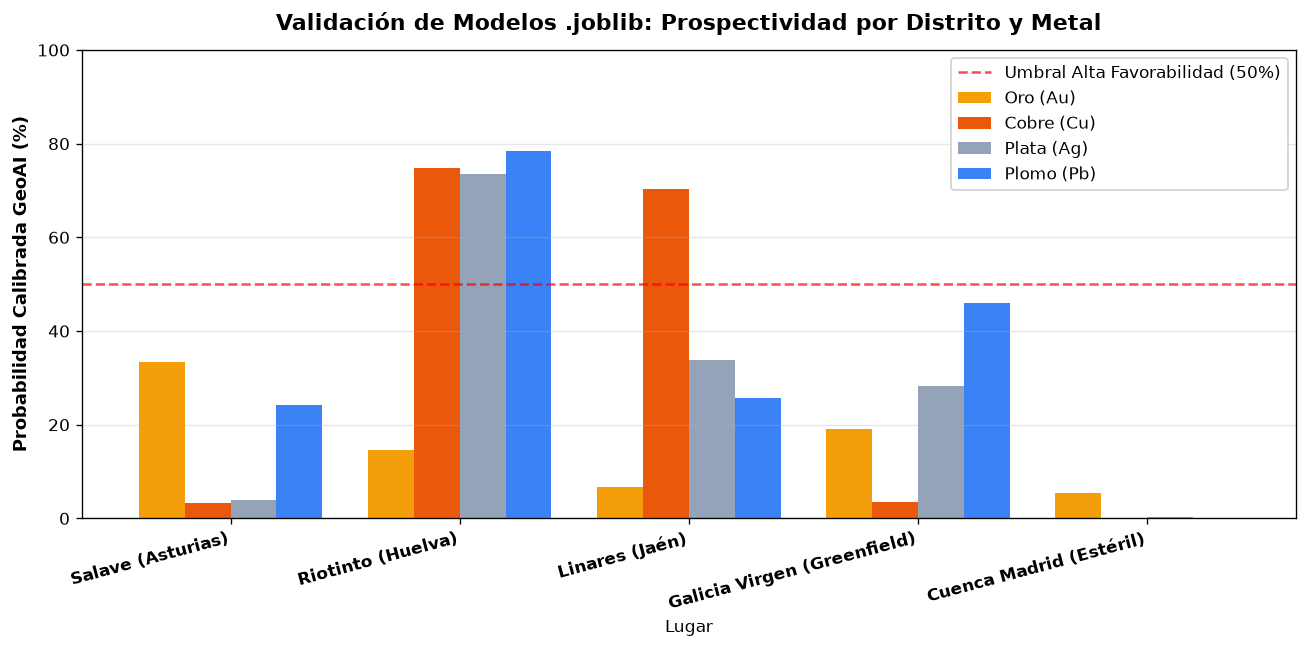

In [8]:
import matplotlib.pyplot as plt

df_comp = pd.DataFrame([
    {'Lugar': 'Salave (Asturias)', 'Oro (Au)': res_salave['p_au']*100, 'Cobre (Cu)': res_salave['p_cu']*100, 'Plata (Ag)': res_salave['p_ag']*100, 'Plomo (Pb)': res_salave['p_pb']*100},
    {'Lugar': 'Riotinto (Huelva)', 'Oro (Au)': res_riotinto['p_au']*100, 'Cobre (Cu)': res_riotinto['p_cu']*100, 'Plata (Ag)': res_riotinto['p_ag']*100, 'Plomo (Pb)': res_riotinto['p_pb']*100},
    {'Lugar': 'Linares (Jaén)', 'Oro (Au)': res_linares['p_au']*100, 'Cobre (Cu)': res_linares['p_cu']*100, 'Plata (Ag)': res_linares['p_ag']*100, 'Plomo (Pb)': res_linares['p_pb']*100},
    {'Lugar': 'Galicia Virgen (Greenfield)', 'Oro (Au)': res_greenfield['p_au']*100, 'Cobre (Cu)': res_greenfield['p_cu']*100, 'Plata (Ag)': res_greenfield['p_ag']*100, 'Plomo (Pb)': res_greenfield['p_pb']*100},
    {'Lugar': 'Cuenca Madrid (Estéril)', 'Oro (Au)': res_cuenca['p_au']*100, 'Cobre (Cu)': res_cuenca['p_cu']*100, 'Plata (Ag)': res_cuenca['p_ag']*100, 'Plomo (Pb)': res_cuenca['p_pb']*100}
])

fig, ax = plt.subplots(figsize=(11, 5.5), dpi=120)
df_comp.set_index('Lugar').plot(kind='bar', ax=ax, color=['#f59e0b', '#ea580c', '#94a3b8', '#3b82f6'], width=0.8)
ax.set_ylabel("Probabilidad Calibrada GeoAI (%)", fontsize=11, fontweight='bold')
ax.set_title("Validación de Modelos .joblib: Prospectividad por Distrito y Metal", fontsize=13, fontweight='bold', pad=12)
ax.axhline(50.0, color='red', linestyle='--', alpha=0.7, label='Umbral Alta Favorabilidad (50%)')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)
plt.xticks(rotation=15, ha='right', fontweight='600')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()